# Import Modules 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read CSV

In [3]:
pd.set_option("display.max_columns", 30)

In [4]:
df = pd.read_csv("../csv_files/online_food_delivery_cleaned.csv")
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,2847.50,0.0,2847.50,UPI,Delivered,Order Delivered,DP563,5,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.00,20.0,4849.00,COD,Delivered,Order Delivered,DP369,5,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,39.0,Male,Delhi,East,RES723,Restaurant_244,Arabian,2024-12-08,207.0,20.41,757.00,20.0,737.00,Wallet,Delivered,Order Delivered,DP580,4,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,2283.25,50.0,2233.25,UPI,Cancelled,Late Delivery,DP155,0,3.4,Weekday,True,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.00,20.0,352.00,Card,Delivered,Order Delivered,DP728,2,4.4,Weekend,False,0.12


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  str    
 1   Customer_ID          100000 non-null  str    
 2   Customer_Age         100000 non-null  float64
 3   Customer_Gender      100000 non-null  str    
 4   City                 100000 non-null  str    
 5   Area                 100000 non-null  str    
 6   Restaurant_ID        100000 non-null  str    
 7   Restaurant_Name      100000 non-null  str    
 8   Cuisine_Type         100000 non-null  str    
 9   Order_Date           100000 non-null  str    
 10  Delivery_Time_Min    100000 non-null  float64
 11  Distance_km          100000 non-null  float64
 12  Order_Value          100000 non-null  float64
 13  Discount_Applied     100000 non-null  float64
 14  Final_Amount         100000 non-null  float64
 15  Payment_Mode         100000 n

### Converting `Order_Date` column into `datetime`

In [6]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Exploratory Data Analysis

### Distribution of order values and delivery date

In [7]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Order_Date', 'Delivery_Time_Min', 'Distance_km', 'Order_Value',
       'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status',
       'Cancellation_Reason', 'Delivery_Partner_ID', 'Delivery_Rating',
       'Restaurant_Rating', 'Order_Day', 'Peak_Hour', 'Profit_Margin'],
      dtype='str')

Text(0, 0.5, 'Count')

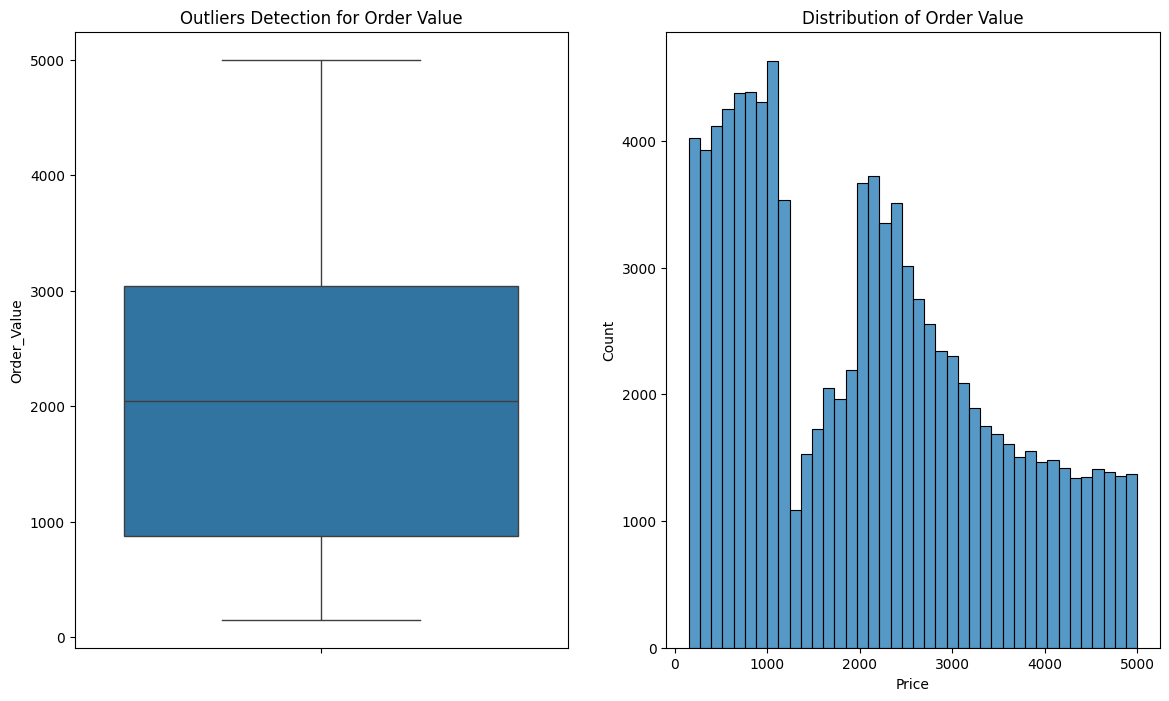

In [8]:
plt.figure(figsize=(14, 8))

plt.subplot(1,2,1)
sns.boxplot(df["Order_Value"])
plt.title("Outliers Detection for Order Value")

plt.subplot(1,2,2)
sns.histplot(df["Order_Value"], bins=40)
plt.title("Distribution of Order Value")
plt.xlabel("Price")
plt.ylabel("Count")



#### Observation
- Boxplot Indicates that there are no outliers in the oreder values.

- Most of the orders happend below 1500, Showing that mos of the customers place low to medium value orders.

### Monthly Sales Records

In [9]:
monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Order_Value"].sum().reset_index()

In [10]:
monthly_sales["Month"] = monthly_sales["Order_Date"].dt.to_timestamp().dt.month_name()

In [11]:
monthly_sales["Order_Value"] = monthly_sales["Order_Value"].astype(int)

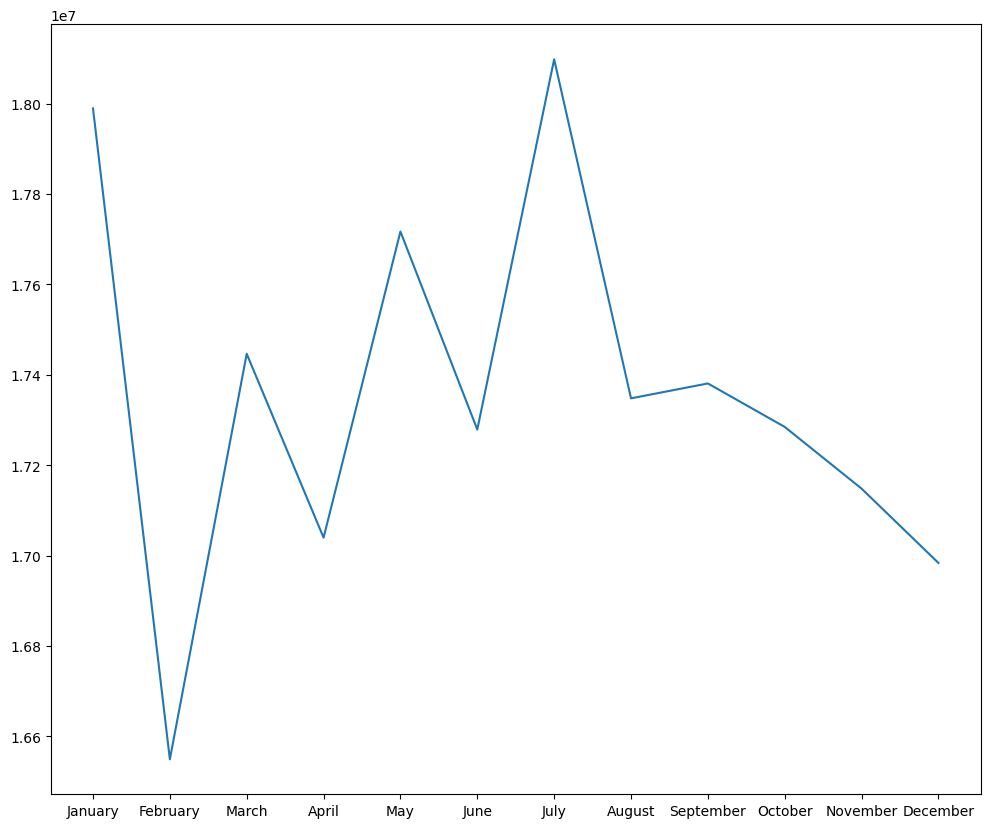

In [12]:
plt.figure(figsize=(12, 10))

plt.plot(monthly_sales["Month"], monthly_sales["Order_Value"])

#### Observation
- In the monthly sales, the highest sales happened in January and July, and the fewest orders were placed in the month of February.

### City-wise and cuisine-wise order analysis

In [13]:
features = ["City", "Cuisine_Type"]

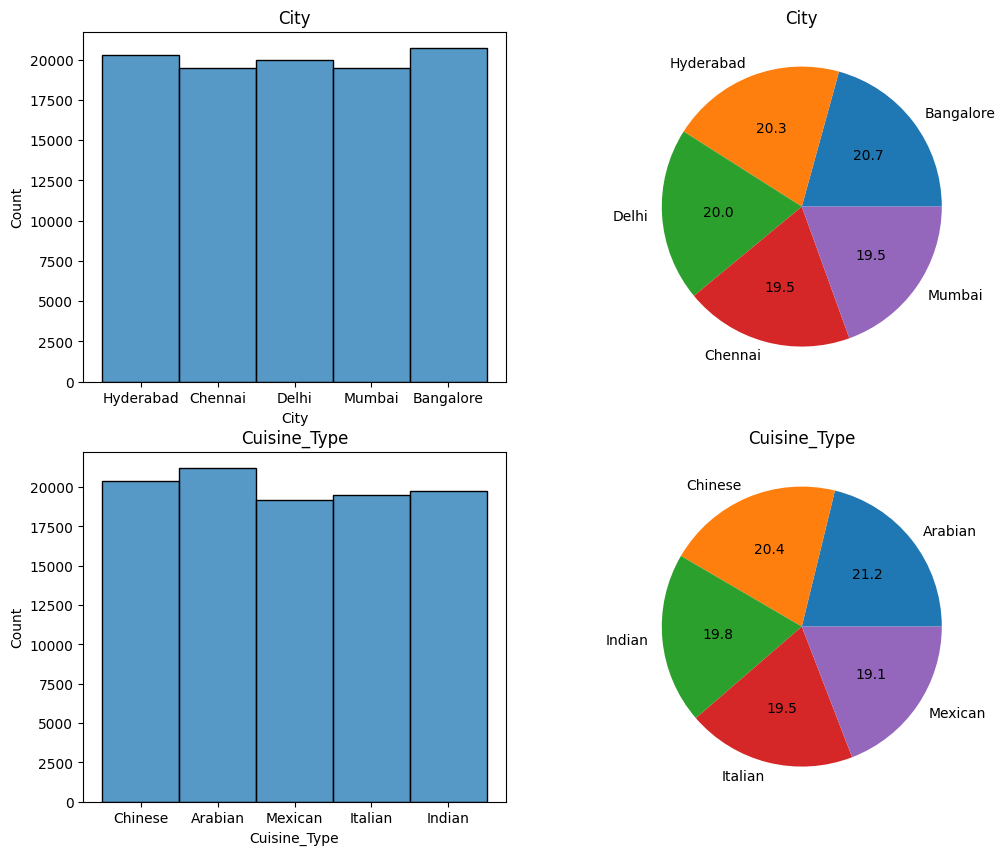

In [14]:
plt.figure(figsize=(12,10))

# City Column
plt.subplot(2,2,1)
sns.histplot(df["City"])
plt.title("City")

plt.subplot(2,2,2)
city = df["City"].value_counts()
plt.pie(city,labels=city.index,  autopct="%1.1f")
plt.title("City")

# Cuisine_Type Column
plt.subplot(2,2,3)
sns.histplot(df["Cuisine_Type"])
plt.title("Cuisine_Type")

plt.subplot(2,2,4)
cuisine = df["Cuisine_Type"].value_counts()
plt.pie(cuisine, labels=cuisine.index,  autopct="%1.1f")
plt.title("Cuisine_Type")
plt.show()

#### Conclusion
- `City` : The dataset is almost perfectly balanced across all five cities, with each city accounting for roughly 20% of total orders.

- `Cuisine_type` : Cuisine is also almost perfectly balanced across all five types. Arabian is the most frequent cuisine type at 21.2%, and Mexican is the least frequent type at 19.1%.

### Weekend vs weekday demand

In [15]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,2847.50,0.0,2847.50,UPI,Delivered,Order Delivered,DP563,5,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.00,20.0,4849.00,COD,Delivered,Order Delivered,DP369,5,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,39.0,Male,Delhi,East,RES723,Restaurant_244,Arabian,2024-12-08,207.0,20.41,757.00,20.0,737.00,Wallet,Delivered,Order Delivered,DP580,4,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,2283.25,50.0,2233.25,UPI,Cancelled,Late Delivery,DP155,0,3.4,Weekday,True,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.00,20.0,352.00,Card,Delivered,Order Delivered,DP728,2,4.4,Weekend,False,0.12


In [16]:
sales_weekday_weekend = df["Order_Day"].value_counts().reset_index()
sales_weekday_weekend.columns = ["Order_Day", "Count"]

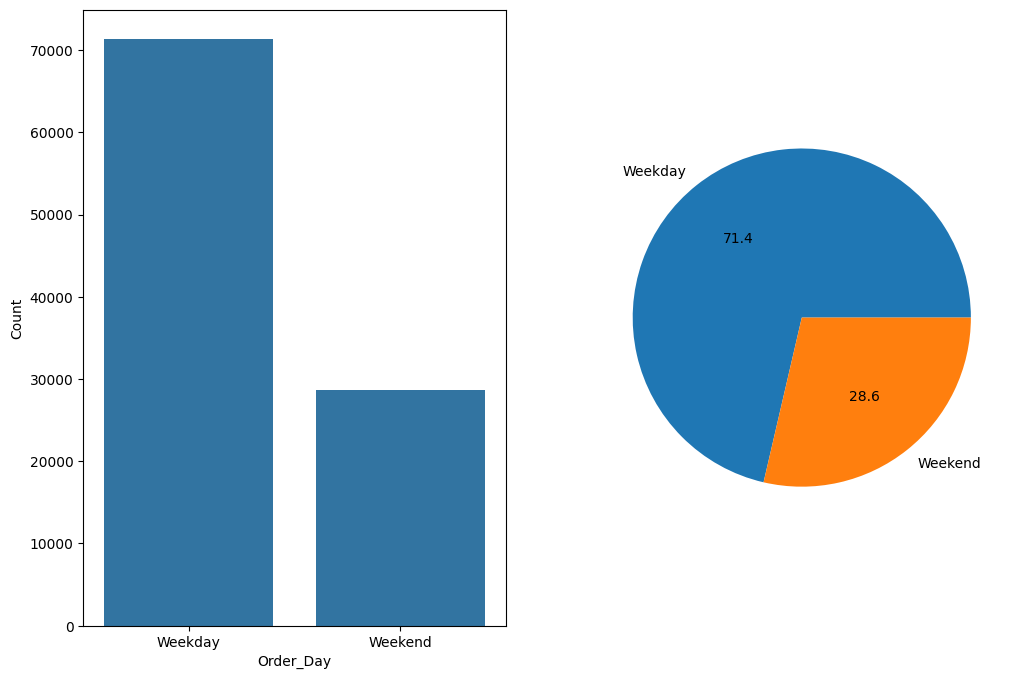

In [17]:
plt.figure(figsize=(12, 8))

plt.subplot(1,2,1)
sns.barplot(data=sales_weekday_weekend,x="Order_Day", y="Count")

plt.subplot(1,2,2)
plt.pie(sales_weekday_weekend["Count"], labels=sales_weekday_weekend["Order_Day"],autopct="%1.1f")

plt.show()

#### Conclusion
- `Order Day`: Most of the orders are placed on weekdays, which makes up 71.4% of the total data (over 70,000 orders). Weekends make up the rest at 28.6% (around 28,500 orders).

In [18]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,2847.50,0.0,2847.50,UPI,Delivered,Order Delivered,DP563,5,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.00,20.0,4849.00,COD,Delivered,Order Delivered,DP369,5,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,39.0,Male,Delhi,East,RES723,Restaurant_244,Arabian,2024-12-08,207.0,20.41,757.00,20.0,737.00,Wallet,Delivered,Order Delivered,DP580,4,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,2283.25,50.0,2233.25,UPI,Cancelled,Late Delivery,DP155,0,3.4,Weekday,True,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.00,20.0,352.00,Card,Delivered,Order Delivered,DP728,2,4.4,Weekend,False,0.12


### Distance vs Delivery Time Relationship

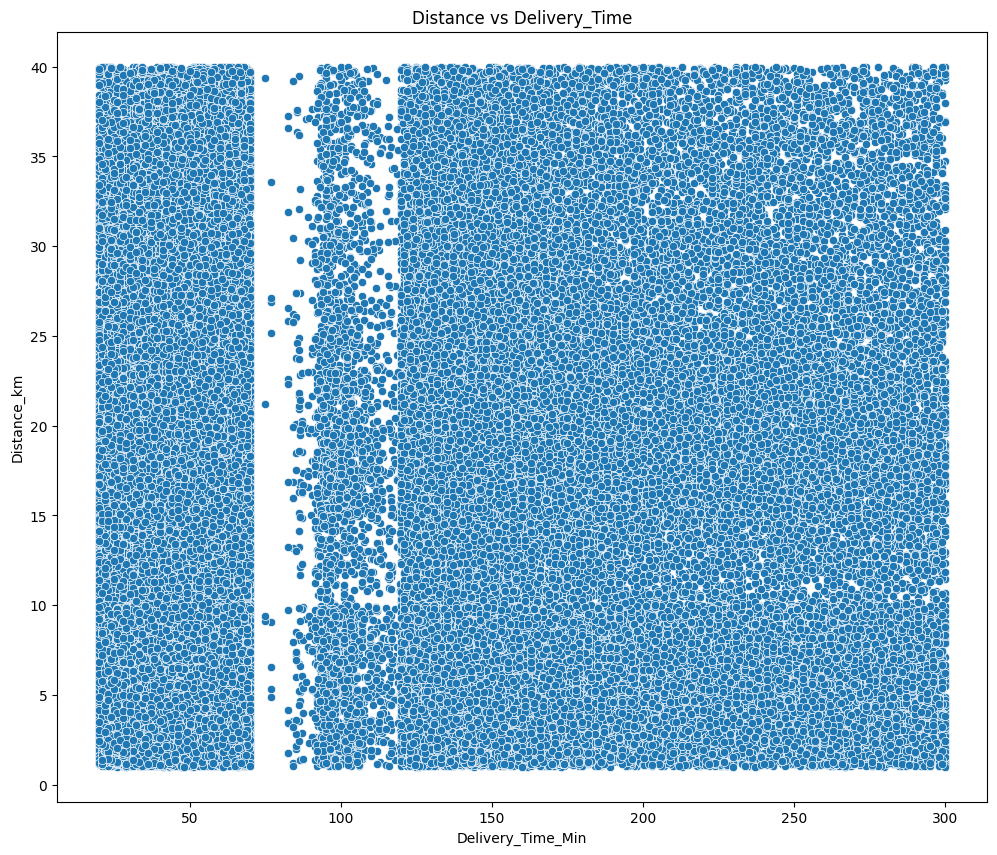

In [19]:
plt.figure(figsize=(12, 10))
sns.scatterplot(data=df, x="Delivery_Time_Min", y="Distance_km")
plt.title("Distance vs Delivery_Time")
plt.show()

#### Conclusion
- There are no relationship between `Distance` and `Delivery Time`.
- It look completly random, for example , a distance of just 1Km can take 40Min

### Cancellation reasons analysis

In [20]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,2847.50,0.0,2847.50,UPI,Delivered,Order Delivered,DP563,5,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.00,20.0,4849.00,COD,Delivered,Order Delivered,DP369,5,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,39.0,Male,Delhi,East,RES723,Restaurant_244,Arabian,2024-12-08,207.0,20.41,757.00,20.0,737.00,Wallet,Delivered,Order Delivered,DP580,4,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,2283.25,50.0,2233.25,UPI,Cancelled,Late Delivery,DP155,0,3.4,Weekday,True,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.00,20.0,352.00,Card,Delivered,Order Delivered,DP728,2,4.4,Weekend,False,0.12


In [21]:
cancellation = df["Order_Status"].value_counts().sort_index().sort_index(ascending=False)

cancellation_reason = df["Cancellation_Reason"].value_counts()
cancellation_reason.drop("Order Delivered", inplace=True)

In [22]:
cancellation

Order_Status
Delivered    84964
Cancelled    15036
Name: count, dtype: int64

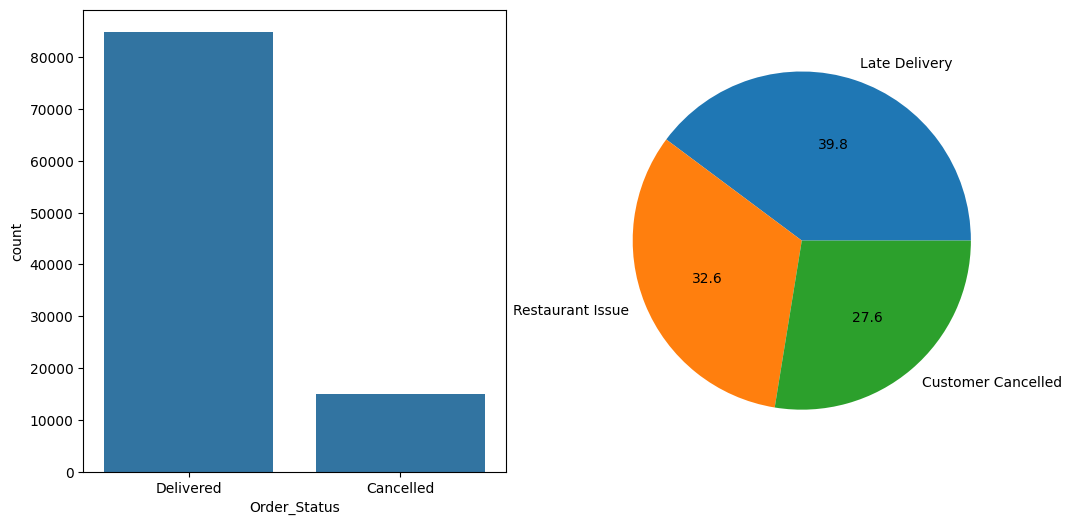

In [23]:
plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
sns.barplot(data=cancellation)

plt.subplot(1,2,2)
plt.pie(cancellation_reason, labels=cancellation_reason.index, autopct="%1.1f")

plt.show()

#### Conclusion
- Total Cancellation : There was  total of `15036` orders cancelled.

- The highest percentage of orders were canceled due to Late Delivery (39.8%) and least cancellation reason was by customer(27.6%).

### Correlation analysis among numeric features

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Order_ID             100000 non-null  str           
 1   Customer_ID          100000 non-null  str           
 2   Customer_Age         100000 non-null  float64       
 3   Customer_Gender      100000 non-null  str           
 4   City                 100000 non-null  str           
 5   Area                 100000 non-null  str           
 6   Restaurant_ID        100000 non-null  str           
 7   Restaurant_Name      100000 non-null  str           
 8   Cuisine_Type         100000 non-null  str           
 9   Order_Date           100000 non-null  datetime64[us]
 10  Delivery_Time_Min    100000 non-null  float64       
 11  Distance_km          100000 non-null  float64       
 12  Order_Value          100000 non-null  float64       
 13  Discount_Applied     10000

In [25]:
numeric_features = df.select_dtypes(include="number")

In [26]:
corr = numeric_features.corr()

In [27]:
corr[corr > 0.01]

,Customer_Age,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Delivery_Rating,Restaurant_Rating,Profit_Margin
Customer_Age,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_Time_Min,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance_km,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
Order_Value,NaN,NaN,NaN,1.000000,NaN,0.997118,NaN,NaN,NaN
Discount_Applied,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
Final_Amount,NaN,NaN,NaN,0.997118,NaN,1.000000,NaN,NaN,NaN
Delivery_Rating,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
Restaurant_Rating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
Profit_Margin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


<Axes: >

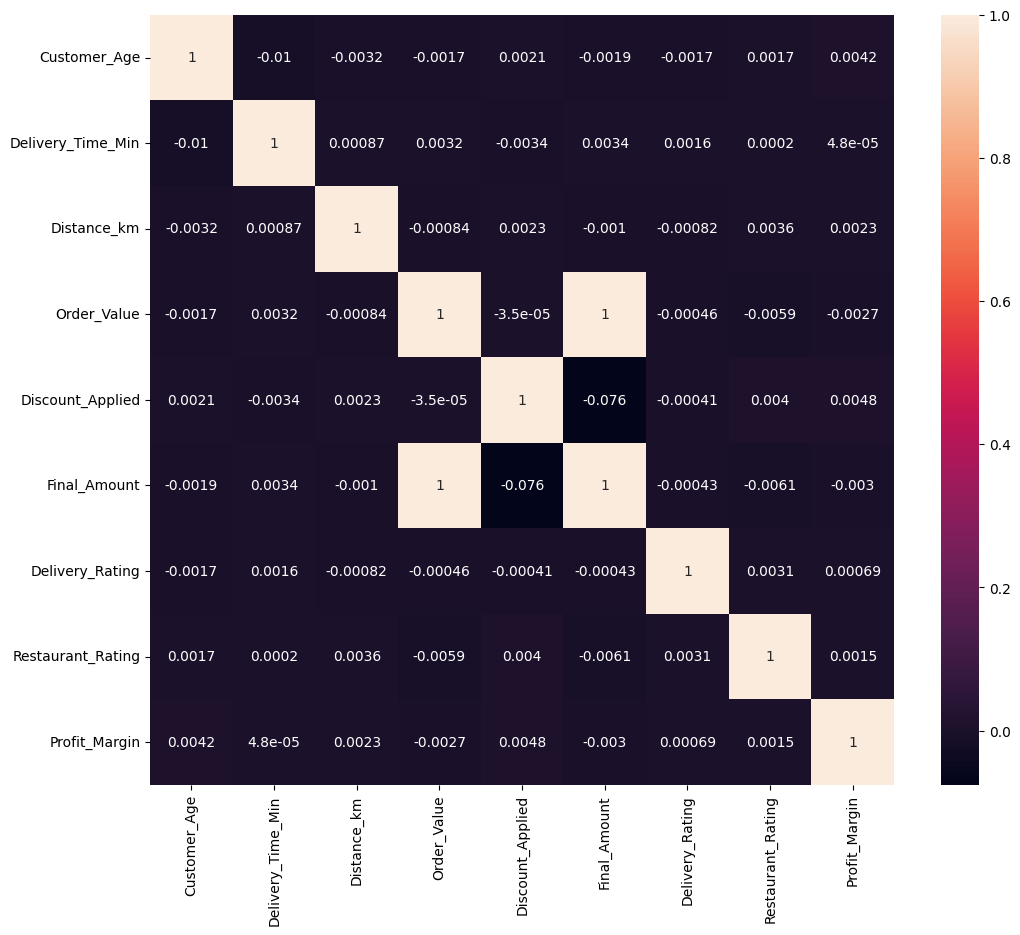

In [28]:
plt.figure(figsize=(12,10))

sns.heatmap(numeric_features.corr(), annot=True)

#### Conclusion
- Correlation Analysis: None of the numeric fields have any relationship with each other; almost all correlations are less than 0.01 (1%).

- Except Order Value, Discount, Final Amount which show logical connection with each other.


# Feature Engineering

### Delivery Performance Categories

In [29]:
df["Delivery_performance_cat"] = df["Delivery_Time_Min"].apply(
    lambda x: "Fast" if x < 30 else "Medium" if x < 60 else "Slow"
)

In [30]:
#df.head()

### Customer Age Groups

In [31]:
df["Customer_Age"].describe()

count    100000.00000
mean         38.98828
std           8.74026
min          18.00000
25%          39.00000
50%          39.00000
75%          39.00000
max          60.00000
Name: Customer_Age, dtype: float64

In [32]:
df["Cus_Age_Group"] = df["Customer_Age"].apply(
    lambda x: "Yound" if (x>= 18 and x <= 30)
    else "Adult" if (x>30 and x <= 50)
    else "Senior"
)

In [33]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Delivery_performance_cat,Cus_Age_Group
0,ORD000001,CUST6948,19.0,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,2847.50,0.0,2847.50,UPI,Delivered,Order Delivered,DP563,5,4.4,Weekend,True,0.13,Slow,Yound
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.00,20.0,4849.00,COD,Delivered,Order Delivered,DP369,5,4.7,Weekday,True,0.48,Fast,Adult
2,ORD000003,CUST1765,39.0,Male,Delhi,East,RES723,Restaurant_244,Arabian,2024-12-08,207.0,20.41,757.00,20.0,737.00,Wallet,Delivered,Order Delivered,DP580,4,4.9,Weekend,True,0.08,Slow,Adult
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,2283.25,50.0,2233.25,UPI,Cancelled,Late Delivery,DP155,0,3.4,Weekday,True,0.04,Slow,Adult
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.00,20.0,352.00,Card,Delivered,Order Delivered,DP728,2,4.4,Weekend,False,0.12,Medium,Senior


### Converting DTypes

In [34]:
df["Customer_Age"] = df["Customer_Age"].astype(int)
df["Delivery_Time_Min"] = df["Delivery_Time_Min"].astype(int)

### Mapping Peak Hour

In [35]:
peak_hour_map = {True:1, False:0}

In [36]:
df["Peak_Hour"] = df["Peak_Hour"].map(peak_hour_map)

### Deriving date column into Date, month, year

In [37]:
df["Ord_Day"] = df["Order_Date"].dt.day
df["Ord_Month"] = df["Order_Date"].dt.month
df["Ord_Year"] = df["Order_Date"].dt.year

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Order_ID                  100000 non-null  str           
 1   Customer_ID               100000 non-null  str           
 2   Customer_Age              100000 non-null  int64         
 3   Customer_Gender           100000 non-null  str           
 4   City                      100000 non-null  str           
 5   Area                      100000 non-null  str           
 6   Restaurant_ID             100000 non-null  str           
 7   Restaurant_Name           100000 non-null  str           
 8   Cuisine_Type              100000 non-null  str           
 9   Order_Date                100000 non-null  datetime64[us]
 10  Delivery_Time_Min         100000 non-null  int64         
 11  Distance_km               100000 non-null  float64       
 12  Order_Value   

# Storing Csv File

In [39]:
df.isnull().sum()

Order_ID                    0
Customer_ID                 0
Customer_Age                0
Customer_Gender             0
City                        0
Area                        0
Restaurant_ID               0
Restaurant_Name             0
Cuisine_Type                0
Order_Date                  0
Delivery_Time_Min           0
Distance_km                 0
Order_Value                 0
Discount_Applied            0
Final_Amount                0
Payment_Mode                0
Order_Status                0
Cancellation_Reason         0
Delivery_Partner_ID         0
Delivery_Rating             0
Restaurant_Rating           0
Order_Day                   0
Peak_Hour                   0
Profit_Margin               0
Delivery_performance_cat    0
Cus_Age_Group               0
Ord_Day                     0
Ord_Month                   0
Ord_Year                    0
dtype: int64

In [40]:
df.to_csv("../csv_files/online_food_delivery_feature.csv", index=False)